### Imports

In [1]:
import os
import io
import re
import base64
import shutil
from pathlib import Path

from dotenv import load_dotenv
from IPython.display import display, Markdown, Image as IPImage

from docling.document_converter import DocumentConverter, PdfFormatOption
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import PdfPipelineOptions

from langchain_core.documents import Document
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langchain_chroma import Chroma
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

load_dotenv(Path("../../.env"))

if not os.getenv("GROQ_API_KEY"):
    raise ValueError("GROQ_API_KEY is missing! Set it in your .env file.")

### Loading Embedding model

In [2]:
embedding_model = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
text_llm = ChatGroq(model_name="openai/gpt-oss-120b", temperature=0.0)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

### Parsing and Chunking

#### 📖 Experiment Source Documents for notebooks
The system indexes and structures context frames using the following documents stored in the local project scope:

| Document ID | Paper Title | Core Scope | Target File |
| :--- | :--- | :--- | :--- |
| **Vaswani et al.** | *Attention Is All You Need* | Transformer Architecture, Self-Attention Mechanisms | `1706.03762v7.pdf` |
| **Lewis et al.** | *Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks* | Hybrid Parametric/Non-Parametric Vector Memory Mapping | `2005.11401v4.pdf` |
| **Brown et al.** | *Language Models are Few-Shot Learners* | GPT-3 In-Context Learning Scaling Laws | `2005.14165v4.pdf` |

In [3]:
data_dir = Path("../data")
PDF_FILES = {
    "attention" : data_dir / "1706.03762v7.pdf",
    "rag"       : data_dir / "2005.11401v4.pdf",
    "gpt3"      : data_dir / "2005.14165v4.pdf",
}

image_raw_store: dict[str, str] = {}
table_raw_store: dict[str, str] = {}
all_processed_docs: list[Document] = []

text_splitter = RecursiveCharacterTextSplitter(chunk_size=600, chunk_overlap=120)

pipeline_options = PdfPipelineOptions()
pipeline_options.do_table_structure      = True
pipeline_options.do_ocr                  = False
pipeline_options.generate_page_images    = False
pipeline_options.generate_picture_images = True
pipeline_options.images_scale            = 1.0   # higher res ensures image data is populated

converter = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(pipeline_options=pipeline_options)
    }
)

def clean_metadata(meta: dict) -> dict:
    return {k: (str(v) if v is not None else "") for k, v in meta.items()}

def is_real_data_table(table) -> bool:
    """
    Filter out false-positive tables (author blocks, TOCs, etc.).
    Real data tables have >= 3 rows and contain at least one numeric cell.
    """
    if not table.data or not table.data.grid:
        return False
    rows = table.data.grid
    if len(rows) < 3:
        return False
    has_numeric = any(
        any(
            any(ch.isdigit() for ch in (cell.text or ""))
            for cell in row
            if cell is not None
        )
        for row in rows
    )
    return has_numeric

def summarize_image_with_llm(b64_str: str, label: str, page_num: int) -> str:
    """
    Send the figure to the LLM vision endpoint and get a real descriptive summary.
    Uses Groq's vision-capable model.
    """
    vision_llm = ChatGroq(model_name="meta-llama/llama-4-scout-17b-16e-instruct", temperature=0.0)

    message = HumanMessage(content=[
        {
            "type": "image_url",
            "image_url": {"url": f"data:image/png;base64,{b64_str}"}
        },
        {
            "type": "text",
            "text": (
                f"This figure is from the '{label}' research paper, page {page_num}. "
                "Describe what this figure shows in detail: include any architecture components, "
                "flow of data, labels, axes, values, or structural relationships visible. "
                "Be specific and technical. Keep it under 150 words."
            )
        }
    ])

    try:
        response = vision_llm.invoke([message])
        return response.content.strip()
    except Exception as e:
        print(f"  └─ [Vision LLM] failed for img {label} p{page_num}: {e}")
        return f"FIGURE FROM {label.upper()} PAGE {page_num}. Visual content could not be summarized."


for label, path in PDF_FILES.items():
    if not path.exists():
        print(f"[WARNING] Skipping {label}: file not found at {path}")
        continue
    print(f"\nParsing [{label}] -> {path.name}")

    result = converter.convert(str(path))
    doc    = result.document

    # ── Tables ────────────────────────────────────────────────────────────────
    print(f"  Tables found: {len(doc.tables)}")
    kept_tables = 0
    for t_idx, table in enumerate(doc.tables):
        try:
            if not is_real_data_table(table):
                print(f"    [SKIP] Table {t_idx} looks like TOC/author block")
                continue

            markdown_table = table.export_to_markdown(doc)          # ✅ pass doc — fixes deprecation warning
            page_num       = table.prov[0].page_no if table.prov else 0
            table_id       = f"table_{label}_p{page_num}_{t_idx}"
            table_raw_store[table_id] = markdown_table              # stored whole, never chunked

            all_processed_docs.append(Document(
                page_content=(
                    f"RESULTS TABLE FROM {label.upper()} PAGE {page_num}. "
                    f"Contains structured benchmark scores, model comparisons, or experimental metrics:\n"
                    + markdown_table
                ),
                metadata=clean_metadata({
                    "page": page_num, "type": "table",
                    "table_id": table_id, "paper": label, "source": str(path)
                })
            ))
            kept_tables += 1
        except Exception as e:
            print(f"  └─ [Table] idx {t_idx}: {e}")
    print(f"  Tables kept : {kept_tables}")

    # ── Images ────────────────────────────────────────────────────────────────
    print(f"  Figures found: {len(doc.pictures)}")
    for img_idx, figure in enumerate(doc.pictures):
        try:
            page_num = figure.prov[0].page_no if figure.prov else 0
            image_id = f"img_{label}_p{page_num}_{img_idx}"

            pil_image = figure.get_image(doc)                       # ✅ PIL directly — no URI path dependency
            if pil_image is None:
                print(f"    [SKIP] No image data for figure {img_idx} p{page_num}")
                continue

            buffer  = io.BytesIO()
            pil_image.save(buffer, format="PNG")
            b64_str = base64.b64encode(buffer.getvalue()).decode()
            image_raw_store[image_id] = b64_str                     # stored whole, never chunked

            print(f"    Summarizing figure {img_idx} on page {page_num}…")
            summary = summarize_image_with_llm(b64_str, label, page_num)

            all_processed_docs.append(Document(
                page_content=summary,
                metadata=clean_metadata({
                    "page": page_num, "type": "image",
                    "image_id": image_id, "paper": label, "source": str(path)
                })
            ))
        except Exception as e:
            print(f"  └─ [Image] idx {img_idx}: {e}")

    # ── Text chunks ───────────────────────────────────────────────────────────
    # strict_text=True returns ONLY prose — tables and figures already captured above
    text_only = doc.export_to_markdown(strict_text=True)
    temp_doc  = Document(
        page_content=text_only,
        metadata={"page": "0", "type": "text", "paper": label, "source": str(path)}
    )
    chunks = text_splitter.split_documents([temp_doc])
    for c in chunks:
        c.metadata = clean_metadata(c.metadata)
        all_processed_docs.append(c)
    print(f"  Text chunks : {len(chunks)}")

print(f"\n{'='*50}")
print(f"Preprocessing complete.")
print(f"  Total docs : {len(all_processed_docs)}")
print(f"  Tables     : {len(table_raw_store)}")
print(f"  Images     : {len(image_raw_store)}")

The plugin langchain_docling will not be loaded because Docling is being executed with allow_external_plugins=false.



Parsing [attention] -> 1706.03762v7.pdf


The plugin langchain_docling will not be loaded because Docling is being executed with allow_external_plugins=false.
The plugin langchain_docling will not be loaded because Docling is being executed with allow_external_plugins=false.


Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

The plugin langchain_docling will not be loaded because Docling is being executed with allow_external_plugins=false.
Stage preprocess failed for run 1, pages [15]: std::bad_alloc


...

  Text chunks : 150

Parsing [gpt3] -> 2005.14165v4.pdf


Stage preprocess failed for run 3, pages [14]: std::bad_alloc
Stage preprocess failed for run 3, pages [15]: std::bad_alloc
Stage preprocess failed for run 3, pages [16]: std::bad_alloc
Stage preprocess failed for run 3, pages [17]: std::bad_alloc
Stage preprocess failed for run 3, pages [18]: std::bad_alloc
Stage preprocess failed for run 3, pages [19]: std::bad_alloc
Stage preprocess failed for run 3, pages [20]: std::bad_alloc
Stage preprocess failed for run 3, pages [21]: std::bad_alloc
Stage preprocess failed for run 3, pages [22]: std::bad_alloc
Stage preprocess failed for run 3, pages [23]: std::bad_alloc
Stage preprocess failed for run 3, pages [24]: std::bad_alloc
Stage preprocess failed for run 3, pages [25]: std::bad_alloc
Stage preprocess failed for run 3, pages [26]: std::bad_alloc
Stage preprocess failed for run 3, pages [27]: std::bad_alloc
Stage preprocess failed for run 3, pages [28]: std::bad_alloc
Stage preprocess failed for run 3, pages [29]: std::bad_alloc
Stage pr

  Tables found: 7
    [SKIP] Table 0 looks like TOC/author block
  Tables kept : 6
  Figures found: 7
    Summarizing figure 0 on page 3…
    Summarizing figure 1 on page 4…
    Summarizing figure 2 on page 5…
    Summarizing figure 3 on page 7…
    Summarizing figure 4 on page 9…
    Summarizing figure 5 on page 11…
    Summarizing figure 6 on page 12…


Parameter `strict_text` has been deprecated and will be ignored.


  Text chunks : 130

Preprocessing complete.
  Total docs : 426
  Tables     : 16
  Images     : 15


In [4]:
# DEBUG — remove after confirming
print(f"  doc.tables type: {type(doc.tables)}, len: {len(doc.tables)}")
print(f"  doc.pictures type: {type(doc.pictures)}, len: {len(doc.pictures)}")
for t in doc.tables[:2]:
    print(f"    table prov: {t.prov}, has data: {t.data is not None}")

  doc.tables type: <class 'list'>, len: 7
  doc.pictures type: <class 'list'>, len: 7
    table prov: [ProvenanceItem(page_no=1, bbox=BoundingBox(l=85.35090637207031, t=631.85986328125, r=526.939697265625, b=411.1106872558594, coord_origin=<CoordOrigin.BOTTOMLEFT: 'BOTTOMLEFT'>), charspan=(0, 0))], has data: True
    table prov: [ProvenanceItem(page_no=2, bbox=BoundingBox(l=70.28302764892578, t=694.4077835083008, r=540.608154296875, b=199.83203125, coord_origin=<CoordOrigin.BOTTOMLEFT: 'BOTTOMLEFT'>), charspan=(0, 0))], has data: True


In [5]:
for t_idx, table in enumerate(doc.tables[:3]):
    print(f"\n  Table {t_idx}:")
    print(f"    prov: {table.prov}")
    print(f"    data type: {type(table.data)}")
    try:
        md = table.export_to_markdown()
        print(f"    markdown preview: {repr(md[:200])}")
    except Exception as e:
        print(f"    export_to_markdown() FAILED: {e}")

Usage of TableItem.export_to_markdown() without `doc` argument is deprecated.
Usage of TableItem.export_to_markdown() without `doc` argument is deprecated.
Usage of TableItem.export_to_markdown() without `doc` argument is deprecated.



  Table 0:
    prov: [ProvenanceItem(page_no=1, bbox=BoundingBox(l=85.35090637207031, t=631.85986328125, r=526.939697265625, b=411.1106872558594, coord_origin=<CoordOrigin.BOTTOMLEFT: 'BOTTOMLEFT'>), charspan=(0, 0))]
    data type: <class 'docling_core.types.doc.document.TableData'>
    markdown preview: '| Tom B. Brown ∗              | Tom B. Brown ∗              | Benjamin Mann ∗ Nick        | Benjamin Mann ∗ Nick   | Melanie Subbiah ∗   | Melanie Subbiah ∗   |\n|-----------------------------|--------'

  Table 1:
    prov: [ProvenanceItem(page_no=2, bbox=BoundingBox(l=70.28302764892578, t=694.4077835083008, r=540.608154296875, b=199.83203125, coord_origin=<CoordOrigin.BOTTOMLEFT: 'BOTTOMLEFT'>), charspan=(0, 0))]
    data type: <class 'docling_core.types.doc.document.TableData'>
    markdown preview: '| 1 Introduction   | 1 Introduction                                      | 1 Introduction                                       |   3 |\n|------------------|-------------------------

### Indexing

In [6]:
db_dir = "./chroma_db_docling_multimodal"
shutil.rmtree(db_dir, ignore_errors=True)

vector_store = Chroma.from_documents(
    documents=all_processed_docs,
    embedding=embedding_model,
    collection_name="docling_multimodal_rag",
    persist_directory=db_dir
)

retriever = vector_store.as_retriever(search_kwargs={"k": 10})

print(f"Vector store built at '{db_dir}'")
print(f"Total vectors indexed: {vector_store._collection.count()}")

Vector store built at './chroma_db_docling_multimodal'
Total vectors indexed: 426


### Retrieval

In [7]:
chat_history: list[dict] = []
def retrieve_with_table_guarantee(
    query: str,
    base_retriever,
    vs,
    min_tables: int = 1
) -> list[Document]:
    """
    Run standard retrieval. If fewer than min_tables table chunks come back,
    top-up with a direct metadata-filtered search so table content is
    always represented in the context.
    """
    docs = base_retriever.invoke(query)
    table_hits = [d for d in docs if d.metadata.get("type") == "table"]

    if len(table_hits) < min_tables:
        extra_tables = vs.similarity_search(
            query, k=5,
            filter={"type": "table"}
        )
        existing_contents = {d.page_content for d in docs}
        extras = [d for d in extra_tables if d.page_content not in existing_contents]
        docs = extras[:min_tables] + docs

    return docs

def build_text_payload(
    query: str,
    retrieved_docs: list[Document],
    history: list[dict],
    max_memory_turns: int = 2
) -> list:
    system_prompt = (
        "You are an elite research assistant. Answer using only the provided context blocks.\n"
        "You have access to text chunks, markdown tables, and figure descriptions.\n"
        "Cite every factual claim as [PaperLabel, Page X] inline in your answer.\n"
        "When quoting numbers from tables, reproduce them exactly as they appear."
    )
    context_blocks = []
    for doc in retrieved_docs:
        paper = doc.metadata.get("paper", "?")
        page  = doc.metadata.get("page",  "?")
        dtype = doc.metadata.get("type",  "?")
        context_blocks.append(
            f"[{paper.upper()} | Page {page} | Type: {dtype}]:\n{doc.page_content}"
        )
    compiled_context = "--- CONTEXT ---\n" + "\n\n".join(context_blocks)
    messages = [SystemMessage(content=system_prompt)]
    slice_size = max_memory_turns * 2
    for turn in (history[-slice_size:] if slice_size > 0 else []):
        if turn["role"] == "user":
            messages.append(HumanMessage(content=turn["content"]))
        else:
            messages.append(AIMessage(content=turn["content"]))

    messages.append(HumanMessage(content=f"{compiled_context}\n\nUser Question: {query}"))
    return messages

In [8]:
def render_rich_output(output_text: str, retrieved_chunks: list[Document]) -> None:
    display(Markdown("### 🤖 Response"))
    display(Markdown(output_text))
    display(Markdown("---"))
    display(Markdown("### 📋 Retrieved Sources"))

    printed_assets: set[str] = set()

    for d in retrieved_chunks:
        dtype = d.metadata.get("type")
        paper = d.metadata.get("paper", "?").upper()
        page  = d.metadata.get("page",  "?")
        display(Markdown(f"**`[{paper}]` Page {page}** — *{dtype}*"))
        asset_uid = (
            d.metadata.get("table_id") or
            d.metadata.get("image_id") or
            f"text_{paper}_{page}_{hash(d.page_content)}"
        )
        if asset_uid in printed_assets:
            continue
        printed_assets.add(asset_uid)
        if dtype == "image":
            img_id = d.metadata.get("image_id")
            if img_id and img_id in image_raw_store:
                display(Markdown(f"#### 🖼️ Figure from [{paper}], Page {page}"))
                img_bytes = base64.b64decode(image_raw_store[img_id])
                display(IPImage(data=img_bytes))
            else:
                display(Markdown(f"> _{d.page_content}_"))
        elif dtype == "table":
            table_id = d.metadata.get("table_id")
            display(Markdown(f"#### 📊 Table from [{paper}], Page {page}"))
            if table_id and table_id in table_raw_store:
                display(Markdown(table_raw_store[table_id]))
            else:
                display(Markdown(d.page_content))

        else:
            display(Markdown(f"#### 📄 Text from [{paper}], Page {page}"))
            display(Markdown(f"> {d.page_content[:600]}{'…' if len(d.page_content) > 600 else ''}"))

        display(Markdown("---"))

In [9]:
def run_rag(query: str, max_memory_turns: int = 2) -> None:
    global chat_history
    print(f"\nUser Query: {query}")

    retrieved_chunks = retrieve_with_table_guarantee(
        query=query,
        base_retriever=retriever,
        vs=vector_store,
        min_tables=1
    )

    messages = build_text_payload(
        query=query,
        retrieved_docs=retrieved_chunks,
        history=chat_history,
        max_memory_turns=max_memory_turns
    )

    response    = text_llm.invoke(messages)
    output_text = response.content

    chat_history.append({"role": "user",      "content": query})
    chat_history.append({"role": "assistant", "content": output_text})

    render_rich_output(output_text, retrieved_chunks)


def clear_memory() -> None:
    global chat_history
    chat_history = []
    print("Conversation memory cleared.")

### Validation Testing

Conversation memory cleared.

User Query: Can you describe the visual diagram of the model architecture in the Transformers paper? Please display it.


### 🤖 Response

The paper’s Figure 1 shows the **overall Transformer architecture** as a single diagram that is split into two mirrored halves:

* **Left half – Encoder**  
  * A stack of **N = 6 identical layers** (the base model) is drawn vertically.  
  * Each layer contains two sub‑layers:  
    1. a **multi‑head self‑attention** block, and  
    2. a **position‑wise fully‑connected feed‑forward network**.  
  * Both sub‑layers are wrapped by residual connections followed by layer‑normalisation.  
  * At the bottom of the encoder stack, the input token embeddings are summed with **positional encodings** before entering the first layer.  
  * The output of the top encoder layer is a sequence of continuous representations **z** that is passed to the decoder.  
  * (This structure is described in the text accompanying Figure 1 and in the encoder‑decoder stack description)【ATTENTION, Page 0】【ATTENTION, Page 3】.

* **Right half – Decoder**  
  * A parallel stack of **N = 6 identical layers** is shown.  
  * Each decoder layer has three sub‑layers:  
    1. a **masked multi‑head self‑attention** block (preventing positions from attending to later positions),  
    2. an **encoder‑decoder attention** block that attends to the encoder’s output **z**, and  
    3. a **position‑wise feed‑forward** network.  
  * As with the encoder, each sub‑layer is surrounded by a residual connection and layer‑normalisation.  
  * Positional encodings are added to the target‑side embeddings before the first decoder layer, and the final decoder output is passed through a linear projection and a soft‑max to produce the probability distribution over the next token.  
  * (These details are given in the encoder‑decoder description)【ATTENTION, Page 3】.

* **Multi‑Head Attention sub‑component** (illustrated in a separate diagram on page 4)  
  * The diagram shows three inputs – **Query (Q)**, **Key (K)** and **Value (V)** – each linearly projected to lower‑dimensional spaces (with dimensions *dₖ* and *dᵥ*).  
  * The projected Q, K and V are fed into the **scaled dot‑product attention** mechanism, which computes attention weights as the dot product of Q and K, scaled by √*dₖ*.  
  * The attention outputs from each head are **concatenated** and then passed through a final linear transformation to produce the multi‑head attention output.  
  * (This is the visual description of the multi‑head attention block)【ATTENTION, Page 4】.

Overall, the figure presents the encoder on the left and the decoder on the right, each built from repeated blocks of multi‑head attention and feed‑forward layers, with residual connections, layer normalisation, and positional encodings tying the whole model together.

---

### 📋 Retrieved Sources

...

#### 📄 Text from [ATTENTION], Page 0

> Figure 1: The Transformer - model architecture.

<!-- image -->

The Transformer follows this overall architecture using stacked self-attention and point-wise, fully connected layers for both the encoder and decoder, shown in the left and right halves of Figure 1, respectively.

## 3.1 Encoder and Decoder Stacks

---

**`[ATTENTION]` Page 3** — *image*

#### 🖼️ Figure from [ATTENTION], Page 3

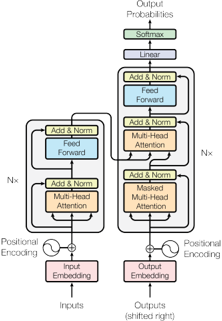

---

**`[ATTENTION]` Page 4** — *image*

#### 🖼️ Figure from [ATTENTION], Page 4

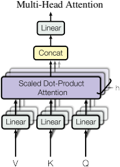

---

**`[ATTENTION]` Page 0** — *text*

#### 📄 Text from [ATTENTION], Page 0

> ## 3 Model Architecture

Most competitive neural sequence transduction models have an encoder-decoder structure [5, 2, 35]. Here, the encoder maps an input sequence of symbol representations ( x 1 , ..., x n ) to a sequence of continuous representations z = ( z 1 , ..., z n ) . Given z , the decoder then generates an output sequence ( y 1 , ..., y m ) of symbols one element at a time. At each step the model is auto-regressive [10], consuming the previously generated symbols as additional input when generating the next.

Figure 1: The Transformer - model architecture.

<!-- image -->

---

**`[ATTENTION]` Page 13** — *image*

#### 🖼️ Figure from [ATTENTION], Page 13

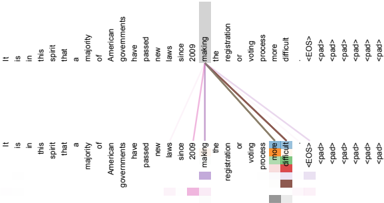

---

**`[GPT3]` Page 0** — *text*

#### 📄 Text from [GPT3], Page 0

> ## 2.1 Model and Architectures

---

...

---

**`[ATTENTION]` Page 0** — *text*

#### 📄 Text from [ATTENTION], Page 0

> <!-- formula-not-decoded -->

Where the projections are parameter matrices W Q i ∈ R d model × d k , W i K ∈ R d model × d k , W V i ∈ R d model × d v and W O ∈ R hd v × d model .

In this work we employ h = 8 parallel attention layers, or heads. For each of these we use d k = d v = d model /h = 64 . Due to the reduced dimension of each head, the total computational cost is similar to that of single-head attention with full dimensionality.

## 3.2.3 Applications of Attention in our Model

The Transformer uses multi-head attention in three different ways:

---

In [10]:
clear_memory()
run_rag("Can you describe the visual diagram of the model architecture in the Transformers paper? Please display it.")

In [11]:
run_rag("What are the precise performance numbers and metrics listed in the results tables for open-domain QA tasks?")


User Query: What are the precise performance numbers and metrics listed in the results tables for open-domain QA tasks?


### 🤖 Response

**Open‑Domain QA results that appear in the supplied tables**

---

### 1. GPT‑3 paper – Table 3.3 (Open‑Domain QA)  
*Metrics: Exact‑Match (EM) on three benchmark sets – Natural Questions (NaturalQS), WebQuestions (WebQS) and TriviaQA.*  

| Setting | NaturalQS | WebQS | TriviaQA |
|---------|-----------|-------|----------|
| RAG (Fine‑tuned, Open‑Domain) [LPP + 20] | 44.5 | 45.5 | 68.0 |
| T5‑11B + SSM (Fine‑tuned, Closed‑Book) [RRS20] | 36.6 | 44.7 | 60.5 |
| T5‑11B (Fine‑tuned, Closed‑Book) | 34.5 | 37.4 | 50.1 |
| GPT‑3 Zero‑Shot | 14.6 | 14.4 | 64.3 |
| GPT‑3 One‑Shot | 23.0 | 25.3 | 68.0 |
| GPT‑3 Few‑Shot | 29.9 | 41.5 | 71.2 |

*Source: GPT‑3, Table 3.3, Page 13*【GPT3 | Page 13 | Type: table】  

---

### 2. RAG paper – Table 1 (Open‑Domain QA Test Scores)  
*Metrics: Exact‑Match (EM) on Natural Questions (NQ), TriviaQA (TQA – two splits), WebQuestions (WQ) and CuratedTREC (CT). The TQA column shows “standard‑test / Wiki‑split” values.*  

| Model | NQ | TQA (standard / Wiki) | WQ | CT |
|-------|----|-----------------------|----|----|
| T5‑11B [52] (Closed‑Book) | 34.5 | – / 50.1 – / 60.5 | 37.4 | – – |
| T5‑11B + SSM [52] (Closed‑Book) | 36.6 | – | 44.7 | – |
| REALM [20] (Open‑Book) | 40.4 | – / – | 40.7 | 46.8 |
| DPR [26] (Open‑Book) | 41.5 | 57.9 / – | 41.1 | 50.6 |
| RAG‑Token | 44.1 | 55.2 / 66.1 | 45.5 | 50.0 |
| RAG‑Seq. | 44.5 | 56.8 / 68.0 | 45.2 | 52.2 |

*Source: RAG, Table 1, Page 6*【RAG | Page 6 | Type: table】  

---

### 3. RAG paper – Table 8 (Extended Open‑Domain QA Metrics)  
*Metrics: Exact‑Match (EM) on NQ, TQA, WQ, CT; BLEU‑1 (B‑1) and QB‑1 on Jeopardy‑QGen; ROUGE‑L (R‑L) and BLEU‑1 on MS‑Marco; Label Accuracy on FVR‑3 and FVR‑2.*  

| Model | NQ (EM) | TQA (EM) | WQ (EM) | CT (EM) | Jeopardy‑QGen B‑1 | Jeopardy‑QGen QB‑1 | MS‑Marco R‑L | MS‑Marco B‑1 | FVR‑3 Label Acc. | FVR‑2 Label Acc. |
|-------|---------|----------|---------|---------|-------------------|--------------------|--------------|--------------|------------------|------------------|
| RAG‑Token‑BM25 | 29.7 | 41.5 | 32.1 | 33.1 | 17.5 | 22.3 | 55.5 | 48.4 | 75.1 | 91.6 |
| RAG‑Sequence‑BM25 | 31.8 | 44.1 | 36.6 | 33.8 | 11.1 | 19.5 | 56.5 | 46.9 | – | – |
| RAG‑Token‑Frozen | 37.8 | 50.1 | 37.1 | 51.1 | 16.7 | 21.7 | 55.9 | 49.4 | 72.9 | 89.4 |
| RAG‑Sequence‑Frozen | 41.2 | 52.1 | 41.8 | 52.6 | 11.8 | 19.6 | 56.7 | 47.3 | – | – |
| RAG‑Token | 43.5 | 54.8 | 46.5 | 51.9 | 17.9 | 22.6 | 56.2 | 49.4 | 74.5 | 90.6 |
| RAG‑Sequence | 44.0 | 55.8 | 44.9 | 53.4 | 15.3 | 21.5 | 57.2 | 47.5 | – | – |

*Source: RAG, Table 8, Page 8*【RAG | Page 8 | Type: table】  

---

#### Summary of the numbers
- **GPT‑3** achieves its best TriviaQA score (71.2 EM) in the few‑shot setting, but lags behind the fine‑tuned RAG baseline (68.0 EM) on the same task.  
- **RAG** (both Token and Sequence variants) consistently outperforms the closed‑book baselines (T5‑11B, T5‑11B + SSM) and earlier open‑book models (REALM, DPR) on NQ, TQA, WQ and CT, reaching up to **44.5 EM** on NQ and **68.0 EM** on the Wiki‑split of TriviaQA.  
- When additional retrieval configurations are added (BM25, frozen retriever, etc.), the EM scores improve further (e.g., **44.0 EM** on NQ for RAG‑Sequence, **55.8 EM** on TQA).  
- Beyond EM, RAG also reports strong generation‑quality metrics on downstream generation tasks (BLEU‑1, ROUGE‑L, label accuracy), with the best values observed for the standard **RAG‑Token** model (e.g., **17.9 BLEU‑1** on Jeopardy‑QGen, **74.5 %** label accuracy on FVR‑3).  

These tables capture the complete set of performance numbers and evaluation metrics that were presented for open‑domain question‑answering in the provided documents.

---

### 📋 Retrieved Sources

...

---

**`[RAG]` Page 7** — *table*

#### 📊 Table from [RAG], Page 7

Table 3: Examples from generation tasks. RAG models generate more specific and factually accurate responses. '?' indicates factually incorrect responses, * indicates partially correct responses.

| Task                           | Input                            | Model            | Generation                                                                                                                                                                                                                                  |
|--------------------------------|----------------------------------|------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| MS- MARCO                      | define middle ear                | BART RAG-T RAG-S | ? The middle ear is the part of the ear between the middle ear and the nose. The middle ear is the portion of the ear internal to the eardrum. The middle ear includes the tympanic cavity and the three ossicles.                          |
| MS- MARCO                      | what currency needed in scotland | BART RAG-T RAG-S | The currency needed in Scotland is Pound sterling. Pound is the currency needed in Scotland. The currency needed in Scotland is the pound sterling.                                                                                         |
| Jeopardy Question Gener -ation | Washington                       | BART RAG-T RAG-S | ? This state has the largest number of counties in the U.S. It's the only U.S. state named for a U.S. president It's the state where you'll find Mount Rainier National Park                                                                |
| Jeopardy Question Gener -ation | The Divine Comedy                | BART RAG-T RAG-S | * This epic poem by Dante is divided into 3 parts: the Inferno, the Purgatorio &the Purgatorio Dante's "Inferno" is the first part of this epic poem This 14th century work is divided into 3 sections: "Inferno", "Purgatorio" &"Paradiso" |

---

In [12]:
run_rag("What parameters are tested for the largest GPT-3 models?")


User Query: What parameters are tested for the largest GPT-3 models?


### 🤖 Response

The paper’s model‑size table lists the following hyper‑parameters for the **largest GPT‑3 model (the 175‑billion‑parameter “GPT‑3” version)**【GPT3 | Page 8 | Type: table】:

| Attribute | Value |
|-----------|-------|
| **Number of parameters** | **175.0 B** |
| **Number of layers** | **96** |
| **Model dimension (d model)** | **12 288** |
| **Number of attention heads** | **96** |
| **Head dimension (d head)** | **128** |
| **Batch size (in tokens)** | **3.2 M** |
| **Learning rate** | **0.6 × 10⁻⁴** |

These are the parameters that were explicitly reported and tested for the biggest GPT‑3 configuration.

---

### 📋 Retrieved Sources

...

---

**`[GPT3]` Page 0** — *text*

#### 📄 Text from [GPT3], Page 0

> Finally, given the broad spectrum of capabilities displayed by GPT-3, we discuss concerns about bias, fairness, and broader societal impacts, and attempt a preliminary analysis of GPT-3's characteristics in this regard.

---


User Query: Compare that to the smallest model evaluated.


### 🤖 Response

**Largest GPT‑3 model (GPT‑3 175 B) vs. Smallest evaluated GPT‑3 model (GPT‑3 Small 125 M)**  

| Attribute | GPT‑3 175 B (largest) | GPT‑3 Small 125 M (smallest) |
|-----------|----------------------|------------------------------|
| Number of parameters | **175.0 B** | **125 M** |
| Number of layers | **96** | **12** |
| Model dimension (d model) | **12 288** | **768** |
| Number of attention heads | **96** | **12** |
| Head dimension (d head) | **128** | **64** |
| Batch size (tokens) | **3.2 M** | **0.5 M** |
| Learning rate | **0.6 × 10⁻⁴** | **6.0 × 10⁻⁴** |

*All values are taken from the model‑size table in the paper*【GPT3 | Page 8 | Type: table】.

**Key differences**

* **Scale:** The largest model has **1,400 ×** more parameters than the smallest (175 B ÷ 125 M ≈ 1,400).  
* **Depth:** Layers increase from 12 to 96 (an 8‑fold increase).  
* **Width:** The hidden dimension grows from 768 to 12 288 (≈ 16× larger).  
* **Attention heads:** From 12 heads to 96 heads (8× more).  
* **Head size:** Remains 128 for the large model but is only 64 for the small one.  
* **Training batch:** The large model is trained with a batch of **3.2 M** tokens, versus **0.5 M** tokens for the small model (≈ 6.4× larger).  
* **Learning rate:** The small model uses a higher learning rate (**6 × 10⁻⁴**) compared with the large model’s lower rate (**0.6 × 10⁻⁴**), reflecting the need for more conservative updates at extreme scale.  

Thus, the smallest evaluated GPT‑3 model is dramatically less deep, wide, and computationally intensive than the 175‑billion‑parameter version, with correspondingly higher learning‑rate settings and smaller training batches.

---

### 📋 Retrieved Sources

...

#### 📄 Text from [GPT3], Page 0

> In addition to all the above, we also train a series of smaller models (ranging from 125 million parameters to 13 billion parameters) in order to compare their performance to GPT-3 in the zero, one and few-shot settings. Broadly, for most tasks we find relatively smooth scaling with model capacity in all three settings; one notable pattern is that the gap between zero-, one-, and few-shot performance often grows with model capacity, perhaps suggesting that larger models are more proficient meta-learners.

---

**`[GPT3]` Page 11** — *image*

#### 🖼️ Figure from [GPT3], Page 11

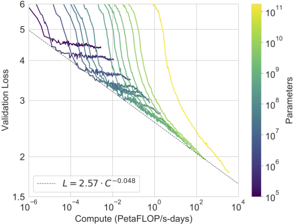

---

**`[GPT3]` Page 9** — *image*

#### 🖼️ Figure from [GPT3], Page 9

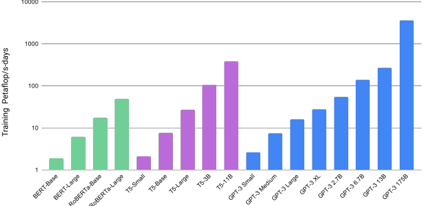

---

**`[GPT3]` Page 5** — *image*

#### 🖼️ Figure from [GPT3], Page 5

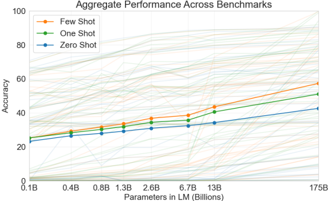

---

**`[ATTENTION]` Page 0** — *text*

#### 📄 Text from [ATTENTION], Page 0

> For the base models, we used a single model obtained by averaging the last 5 checkpoints, which were written at 10-minute intervals. For the big models, we averaged the last 20 checkpoints. We used beam search with a beam size of 4 and length penalty α = 0 . 6 [38]. These hyperparameters were chosen after experimentation on the development set. We set the maximum output length during inference to input length + 50 , but terminate early when possible [38].

---

...

---

**`[RAG]` Page 6** — *table*

#### 📊 Table from [RAG], Page 6

Table 2: Generation and classification Test Scores. MS-MARCO SotA is [4], FEVER-3 is [68] and FEVER-2 is [57] *Uses gold context/evidence. Best model without gold access underlined.

| Model             | Jeopardy   | Jeopardy   | MSMARCO   | MSMARCO   | FVR3   | FVR2 Acc.   |
|-------------------|------------|------------|-----------|-----------|--------|-------------|
| Model             | B-1        | QB-1       | R-L       | B-1       | Label  | Label       |
| SotA              | -          | -          | 49.8 *    | 49.9 *    | 76.8   | 92.2 *      |
| BART              | 15.1       | 19.7       | 38.2      | 41.6      | 64.0   | 81.1        |
| RAG-Tok. RAG-Seq. | 17.3       | 22.2       | 40.1      | 41.5      | 72.5   | 89.5        |
|                   | 14.7       | 21.4       | 40.8      | 44.2      | 72.5   | 89.5        |

---

In [13]:
run_rag("Compare that to the smallest model evaluated.", max_memory_turns=1)